   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Coefficient: 0.41933849393812705
Intercept: 0.4445972916907881

Mean Squared Error: 0.7091157771765548
R² Score: 0.45885918903846656


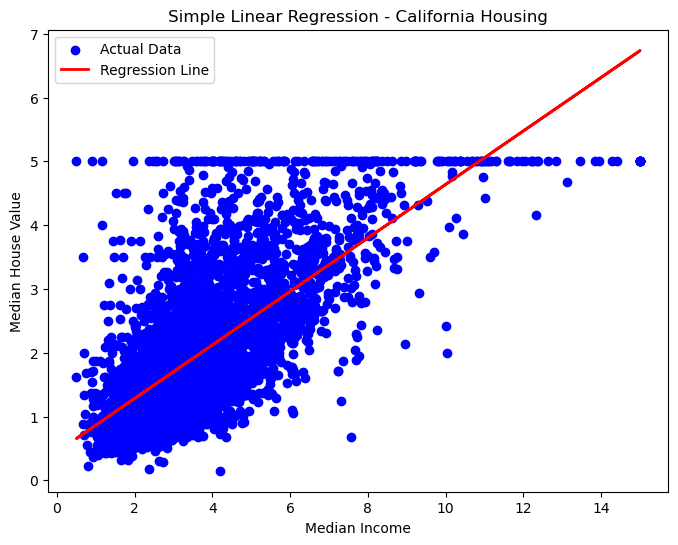

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] = housing.target

# Display first five rows
print(df.head())

# Independent and dependent variables
X = df[["MedInc"]]
y = df["MedHouseVal"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Model parameters
print("\nCoefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nMean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label="Actual Data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression - California Housing")
plt.legend()
plt.show()

First Five Rows:
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  PRICE  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  

Shape of Dataset: (506, 14)

Column Names:
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')

Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0

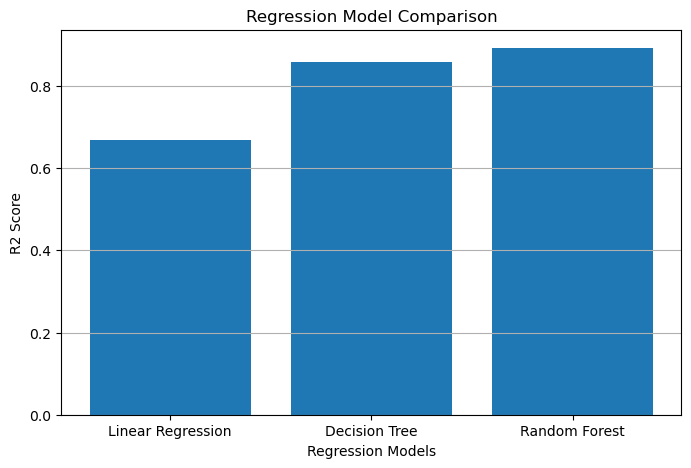

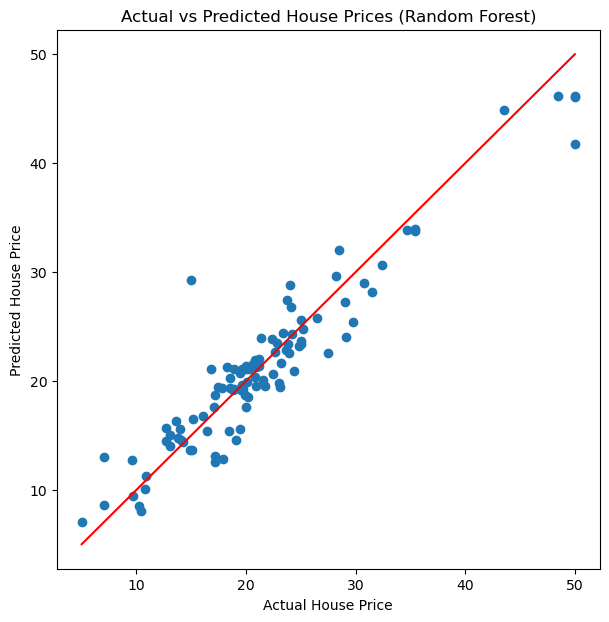


Best Performing Model: Random Forest


In [6]:
# ==========================================
# Boston Housing Price Prediction
# Compare Different Regression Models
# ==========================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# ==========================================
# Load Boston Housing Dataset
# ==========================================

boston = fetch_openml(name="boston", version=1, as_frame=True)

X = boston.data.copy()

# Convert every column to float
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Convert target
y = pd.to_numeric(boston.target, errors="coerce")

# Fill missing values (if any)
X.fillna(X.mean(), inplace=True)
# ==========================================
# Display Dataset Information
# ==========================================

print("First Five Rows:")
print(df.head())

print("\nShape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ==========================================
# Split Dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

# ==========================================
# Linear Regression
# ==========================================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_prediction = linear_model.predict(X_test)

# ==========================================
# Decision Tree Regressor
# ==========================================

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

tree_prediction = tree_model.predict(X_test)

# ==========================================
# Random Forest Regressor
# ==========================================

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_prediction = forest_model.predict(X_test)

# ==========================================
# Evaluation Function
# ==========================================

def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    mse = mean_squared_error(actual, predicted)

    rmse = np.sqrt(mse)

    r2 = r2_score(actual, predicted)

    print("\n===================================")
    print(name)
    print("===================================")
    print("Mean Absolute Error :", mae)
    print("Mean Squared Error  :", mse)
    print("Root Mean Squared Error :", rmse)
    print("R2 Score :", r2)

    return mae, mse, rmse, r2

# ==========================================
# Evaluate Models
# ==========================================

lr_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_prediction
)

dt_results = evaluate_model(
    "Decision Tree Regressor",
    y_test,
    tree_prediction
)

rf_results = evaluate_model(
    "Random Forest Regressor",
    y_test,
    forest_prediction
)

# ==========================================
# Comparison Table
# ==========================================

comparison = pd.DataFrame({

    "Model": [

        "Linear Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "MAE": [

        lr_results[0],

        dt_results[0],

        rf_results[0]

    ],

    "MSE": [

        lr_results[1],

        dt_results[1],

        rf_results[1]

    ],

    "RMSE": [

        lr_results[2],

        dt_results[2],

        rf_results[2]

    ],

    "R2 Score": [

        lr_results[3],

        dt_results[3],

        rf_results[3]

    ]

})

print("\n\nModel Comparison")
print(comparison)

# ==========================================
# Plot R2 Scores
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("Regression Model Comparison")

plt.xlabel("Regression Models")

plt.ylabel("R2 Score")

plt.grid(axis="y")

plt.show()

# ==========================================
# Actual vs Predicted (Random Forest)
# ==========================================

plt.figure(figsize=(7,7))

plt.scatter(y_test, forest_prediction)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices (Random Forest)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

# ==========================================
# Best Model
# ==========================================

best_model = comparison.loc[
    comparison["R2 Score"].idxmax(),
    "Model"
]

print("\nBest Performing Model:", best_model)

In [2]:
import sklearn
print(sklearn.__version__)

1.7.2


In [4]:
print(X.dtypes)
print(X.head())


CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD        category
TAX         float64
PTRATIO     float64
B           float64
LSTAT       float64
dtype: object
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  


In [5]:
print(boston.data.dtypes)

CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD        category
TAX         float64
PTRATIO     float64
B           float64
LSTAT       float64
dtype: object
